In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
data=pd.read_csv("group_30.csv")

In [3]:
# To ensure each colums' data type is correct.
numeric_columns = [
    'age', 'sleep_quality_index', 'brain_fog_level', 'physical_pain_score',
    'stress_level', 'depression_phq9_score', 'fatigue_severity_scale_score',
    'pem_duration_hours', 'hours_of_sleep_per_night'
]
for x in numeric_columns:
    data[x] = pd.to_numeric(data[x])

categorical_columns = [
    'gender', 'work_status', 'social_activity_level', 
    'exercise_frequency', 'meditation_or_mindfulness', 'diagnosis', 'pem_present'
]

for x in categorical_columns: 
    data[x] = data[x].astype('category')

<Figure size 600x400 with 0 Axes>

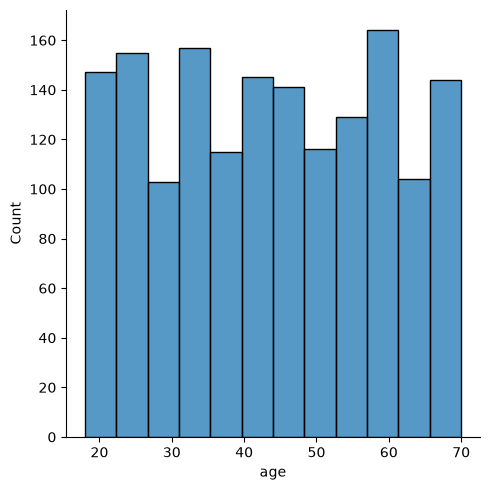

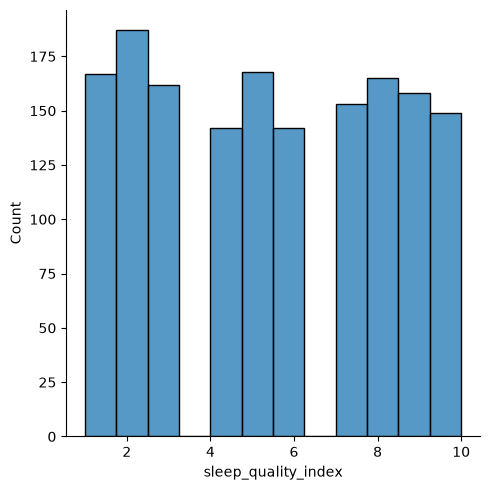

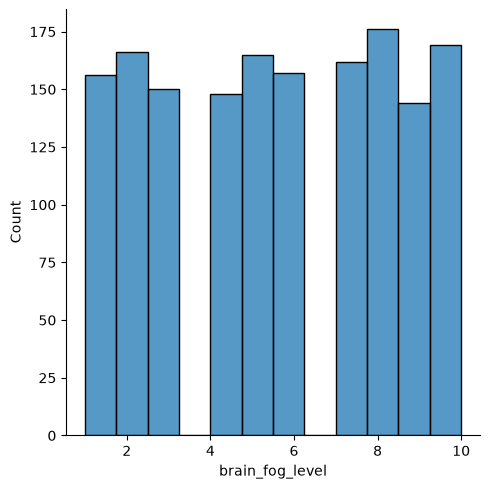

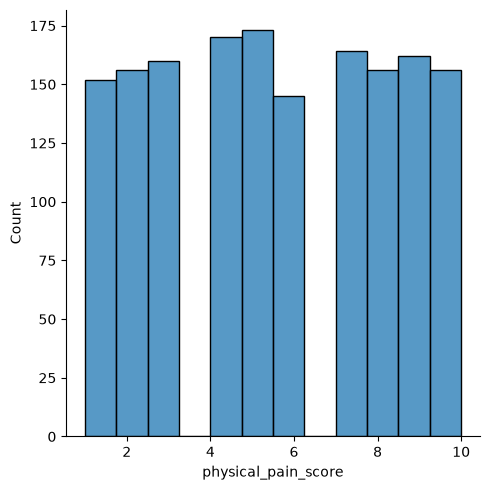

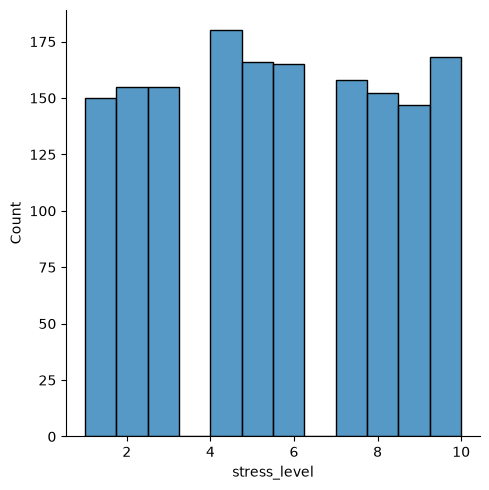

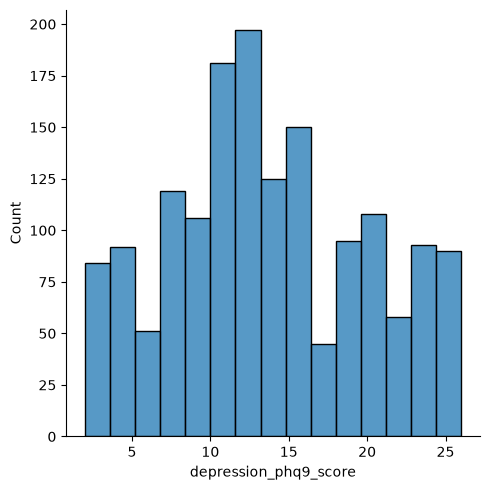

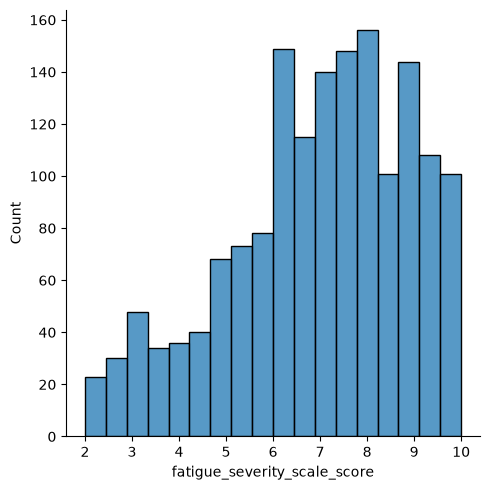

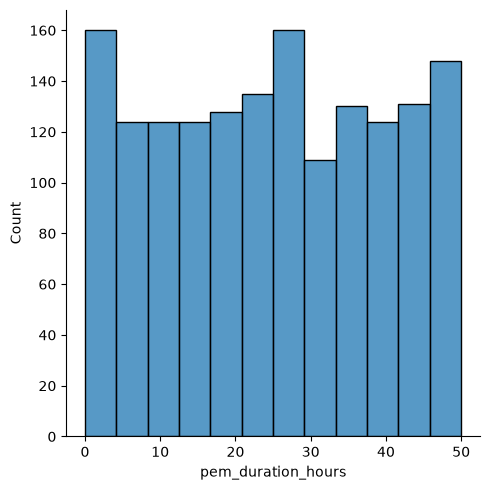

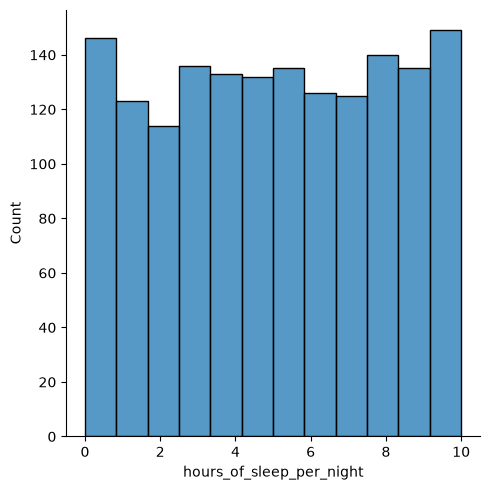

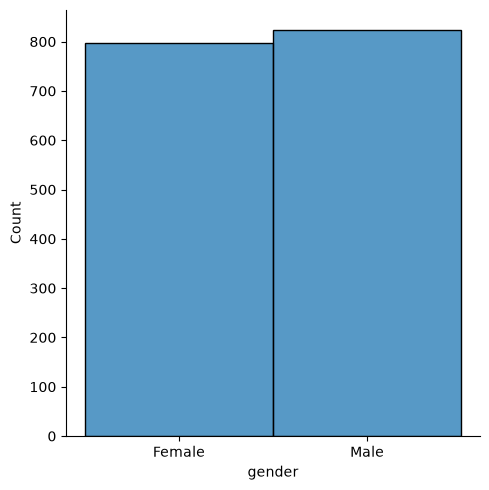

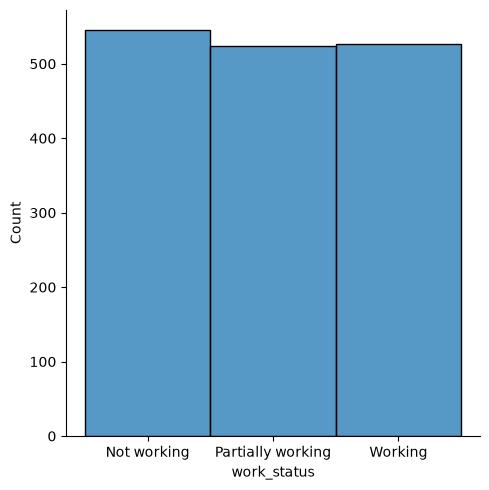

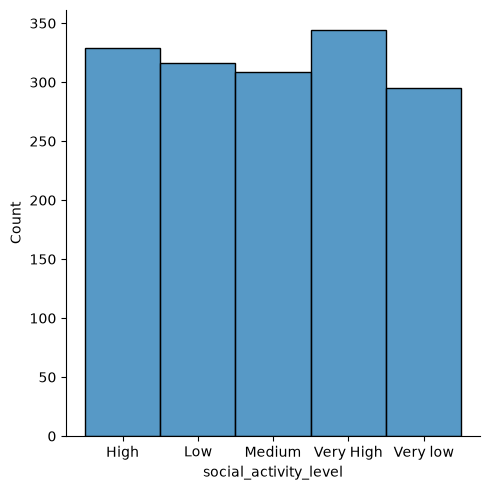

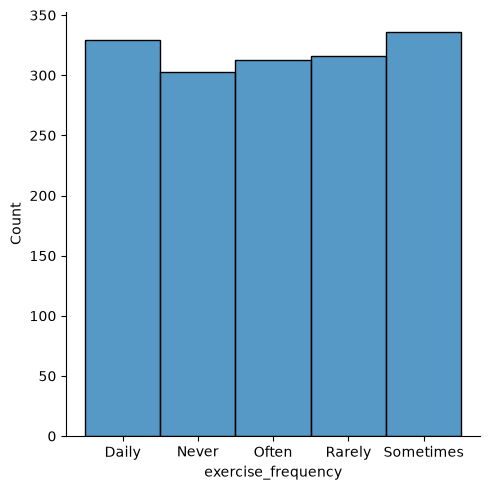

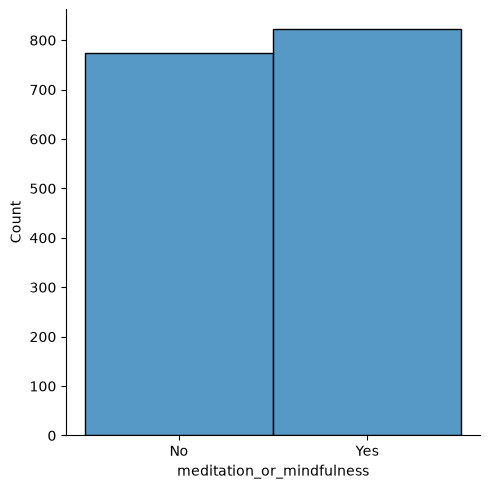

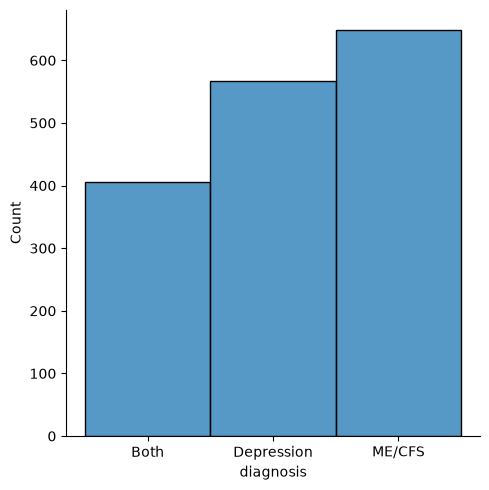

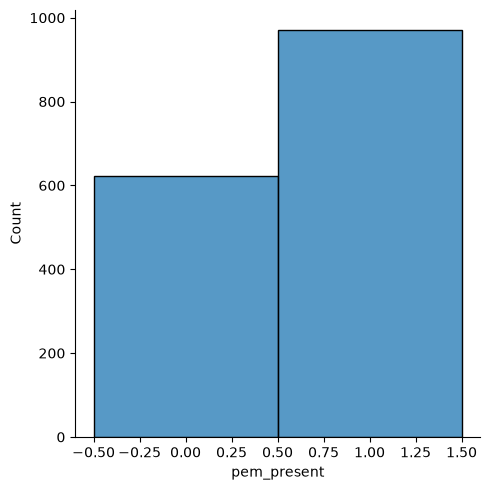

In [4]:
# To check whether there is outlier for certain data
plt.figure(figsize=(6,4))
for z in numeric_columns:
    sns.displot(data=data,x=z)
for y in categorical_columns:
    sns.displot(data=data,x=y)
plt.tight_layout()
plt.show()
# result shows that there is no outlier.

In [5]:
data.isnull().sum()

age                              0
gender                           0
sleep_quality_index             27
brain_fog_level                 27
physical_pain_score             26
stress_level                    24
depression_phq9_score           26
fatigue_severity_scale_score    28
pem_duration_hours              23
hours_of_sleep_per_night        26
pem_present                     28
work_status                     25
social_activity_level           27
exercise_frequency              23
meditation_or_mindfulness       23
diagnosis                        0
dtype: int64

                              Missing values  Misssing percentage%
sleep_quality_index                       27              1.666667
brain_fog_level                           27              1.666667
physical_pain_score                       26              1.604938
stress_level                              24              1.481481
depression_phq9_score                     26              1.604938
fatigue_severity_scale_score              28              1.728395
pem_duration_hours                        23              1.419753
hours_of_sleep_per_night                  26              1.604938
pem_present                               28              1.728395
work_status                               25              1.543210
social_activity_level                     27              1.666667
exercise_frequency                        23              1.419753
meditation_or_mindfulness                 23              1.419753
Correlation between columns having missing values:


<Axes: >

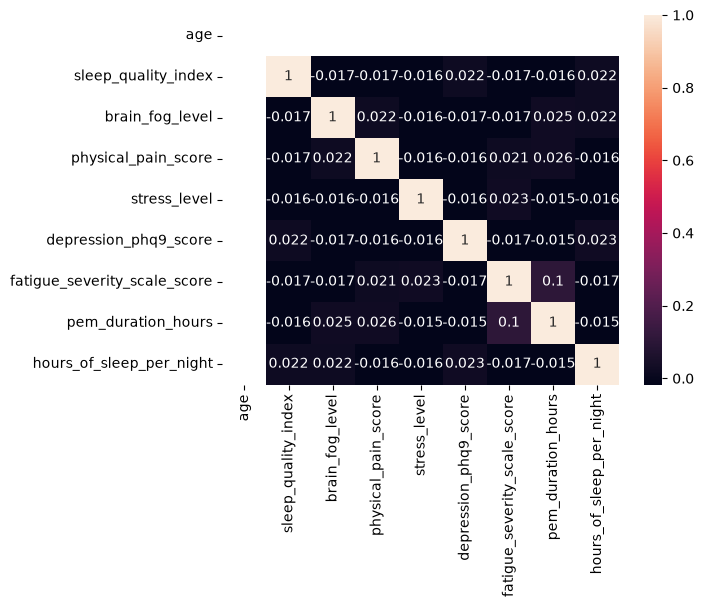

In [6]:
# show the missing value percentage of total, To check whether they can be droped simply
missing_summary = data.isnull().sum()
missing_percent = (missing_summary / len(data)) * 100
missing_info = pd.DataFrame({
    'Missing values': missing_summary,
    'Misssing percentage%': missing_percent
})
print(missing_info[missing_info['Missing values'] > 0])

# To analysis the correlation between the columns having missing values

missing_matrix = data[numeric_columns].isnull()
missing_corr = missing_matrix.corr()
print("Correlation between columns having missing values:")
sns.heatmap(data=missing_corr,annot=True)

In [7]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
# multiple imputation preparation
numeric_imputation_columns = [
    'age', 'sleep_quality_index', 'brain_fog_level', 'physical_pain_score',
    'stress_level', 'depression_phq9_score', 'fatigue_severity_scale_score',
    'pem_duration_hours', 'hours_of_sleep_per_night'
]
data_1 = data.copy()

gender_map = {'Male': 0, 'Female': 1}
data_1['gender_imputated'] = data['gender'].map(gender_map)
numeric_imputation_columns.append('gender_imputated')

diagnosis_map = {'ME/CFS': 0, 'Depression': 1, 'Both': 2}
data_1['diagnosis_imputated'] = data['diagnosis'].map(diagnosis_map)
numeric_imputation_columns.append('diagnosis_imputated')


# multiple imputation processing
imputation_data = data_1[numeric_imputation_columns].copy()

imputer = IterativeImputer(
    estimator=RandomForestRegressor(
        n_estimators=100,
        max_depth=10,
        random_state=42
    ),
    max_iter=20,
    tol=0.01,
    random_state=42,
    initial_strategy='median',
    verbose=1
)

imputed_numeric = imputer.fit_transform(imputation_data)

# prepare the datased after imputation
data_imputed = data.copy()

for i, col in enumerate(numeric_imputation_columns):
    if col in ['age', 'sleep_quality_index', 'brain_fog_level', 'physical_pain_score',
               'stress_level', 'depression_phq9_score', 'fatigue_severity_scale_score',
               'pem_duration_hours', 'hours_of_sleep_per_night']:
        data_imputed[col] = imputed_numeric[:, i]

# use the mode for pem_present variable
if 'pem_present' in data_imputed.columns:
    pem_missing_before = data_imputed['pem_present'].isnull().sum()
    if pem_missing_before > 0:
        data_imputed['pem_present'] = pd.to_numeric(data_imputed['pem_present'])
        pem_mode = data_imputed['pem_present'].mode()
        if len(pem_mode) > 0:
            data_imputed['pem_present'] = data_imputed['pem_present'].fillna(pem_mode[0])
            print(f"  pem_present: filled {pem_missing_before} missing values with mode ({pem_mode[0]})")


categorical_columns = ['work_status', 'social_activity_level', 'exercise_frequency', 'meditation_or_mindfulness']

for col in categorical_columns:
    if data_imputed[col].isnull().sum() > 0:
        mode_val = data_imputed[col].mode()
        if len(mode_val) > 0:
            data_imputed[col] = data_imputed[col].fillna(mode_val[0])
            print(f"  {col}: filled with mode '{mode_val[0]}'")

[IterativeImputer] Completing matrix with shape (1620, 11)
[IterativeImputer] Change: 6.630115995115997, scaled tolerance: 0.7000000000000001 
[IterativeImputer] Change: 2.443074555562866, scaled tolerance: 0.7000000000000001 
[IterativeImputer] Change: 2.1863813753147703, scaled tolerance: 0.7000000000000001 
[IterativeImputer] Change: 1.8758689012226402, scaled tolerance: 0.7000000000000001 
[IterativeImputer] Change: 1.5095838773464472, scaled tolerance: 0.7000000000000001 
[IterativeImputer] Change: 1.1941286021421131, scaled tolerance: 0.7000000000000001 
[IterativeImputer] Change: 2.522291395128118, scaled tolerance: 0.7000000000000001 
[IterativeImputer] Change: 1.906929953157583, scaled tolerance: 0.7000000000000001 
[IterativeImputer] Change: 2.106677723047305, scaled tolerance: 0.7000000000000001 
[IterativeImputer] Change: 1.4638325066556668, scaled tolerance: 0.7000000000000001 
[IterativeImputer] Change: 1.876587486425887, scaled tolerance: 0.7000000000000001 
[IterativeIm

In [8]:
data_imputed.isnull().sum()

age                             0
gender                          0
sleep_quality_index             0
brain_fog_level                 0
physical_pain_score             0
stress_level                    0
depression_phq9_score           0
fatigue_severity_scale_score    0
pem_duration_hours              0
hours_of_sleep_per_night        0
pem_present                     0
work_status                     0
social_activity_level           0
exercise_frequency              0
meditation_or_mindfulness       0
diagnosis                       0
dtype: int64

In [9]:
# use new datasets
data=pd.read_csv("group_30_multiple_imputed.csv")

In [10]:
data.drop_duplicates(inplace=True)

<Figure size 1500x1000 with 0 Axes>

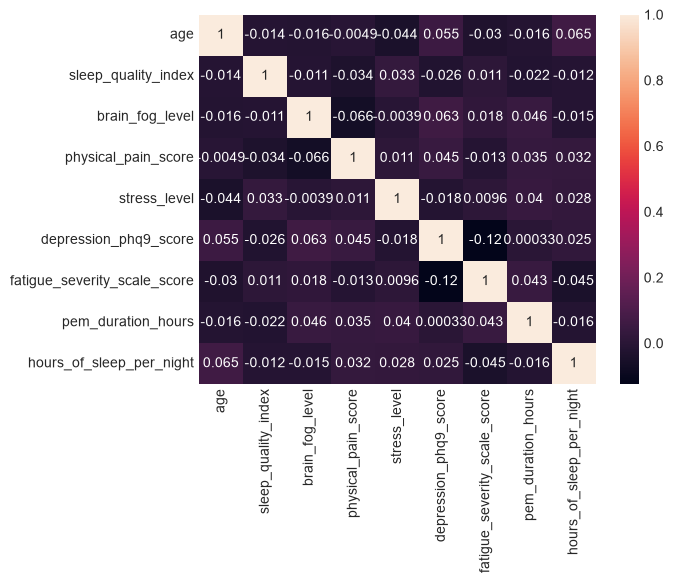

<Figure size 1500x1000 with 0 Axes>

In [13]:
sns.heatmap(data[numeric_columns].corr(),annot=True)
plt.figure(figsize=(15, 10))

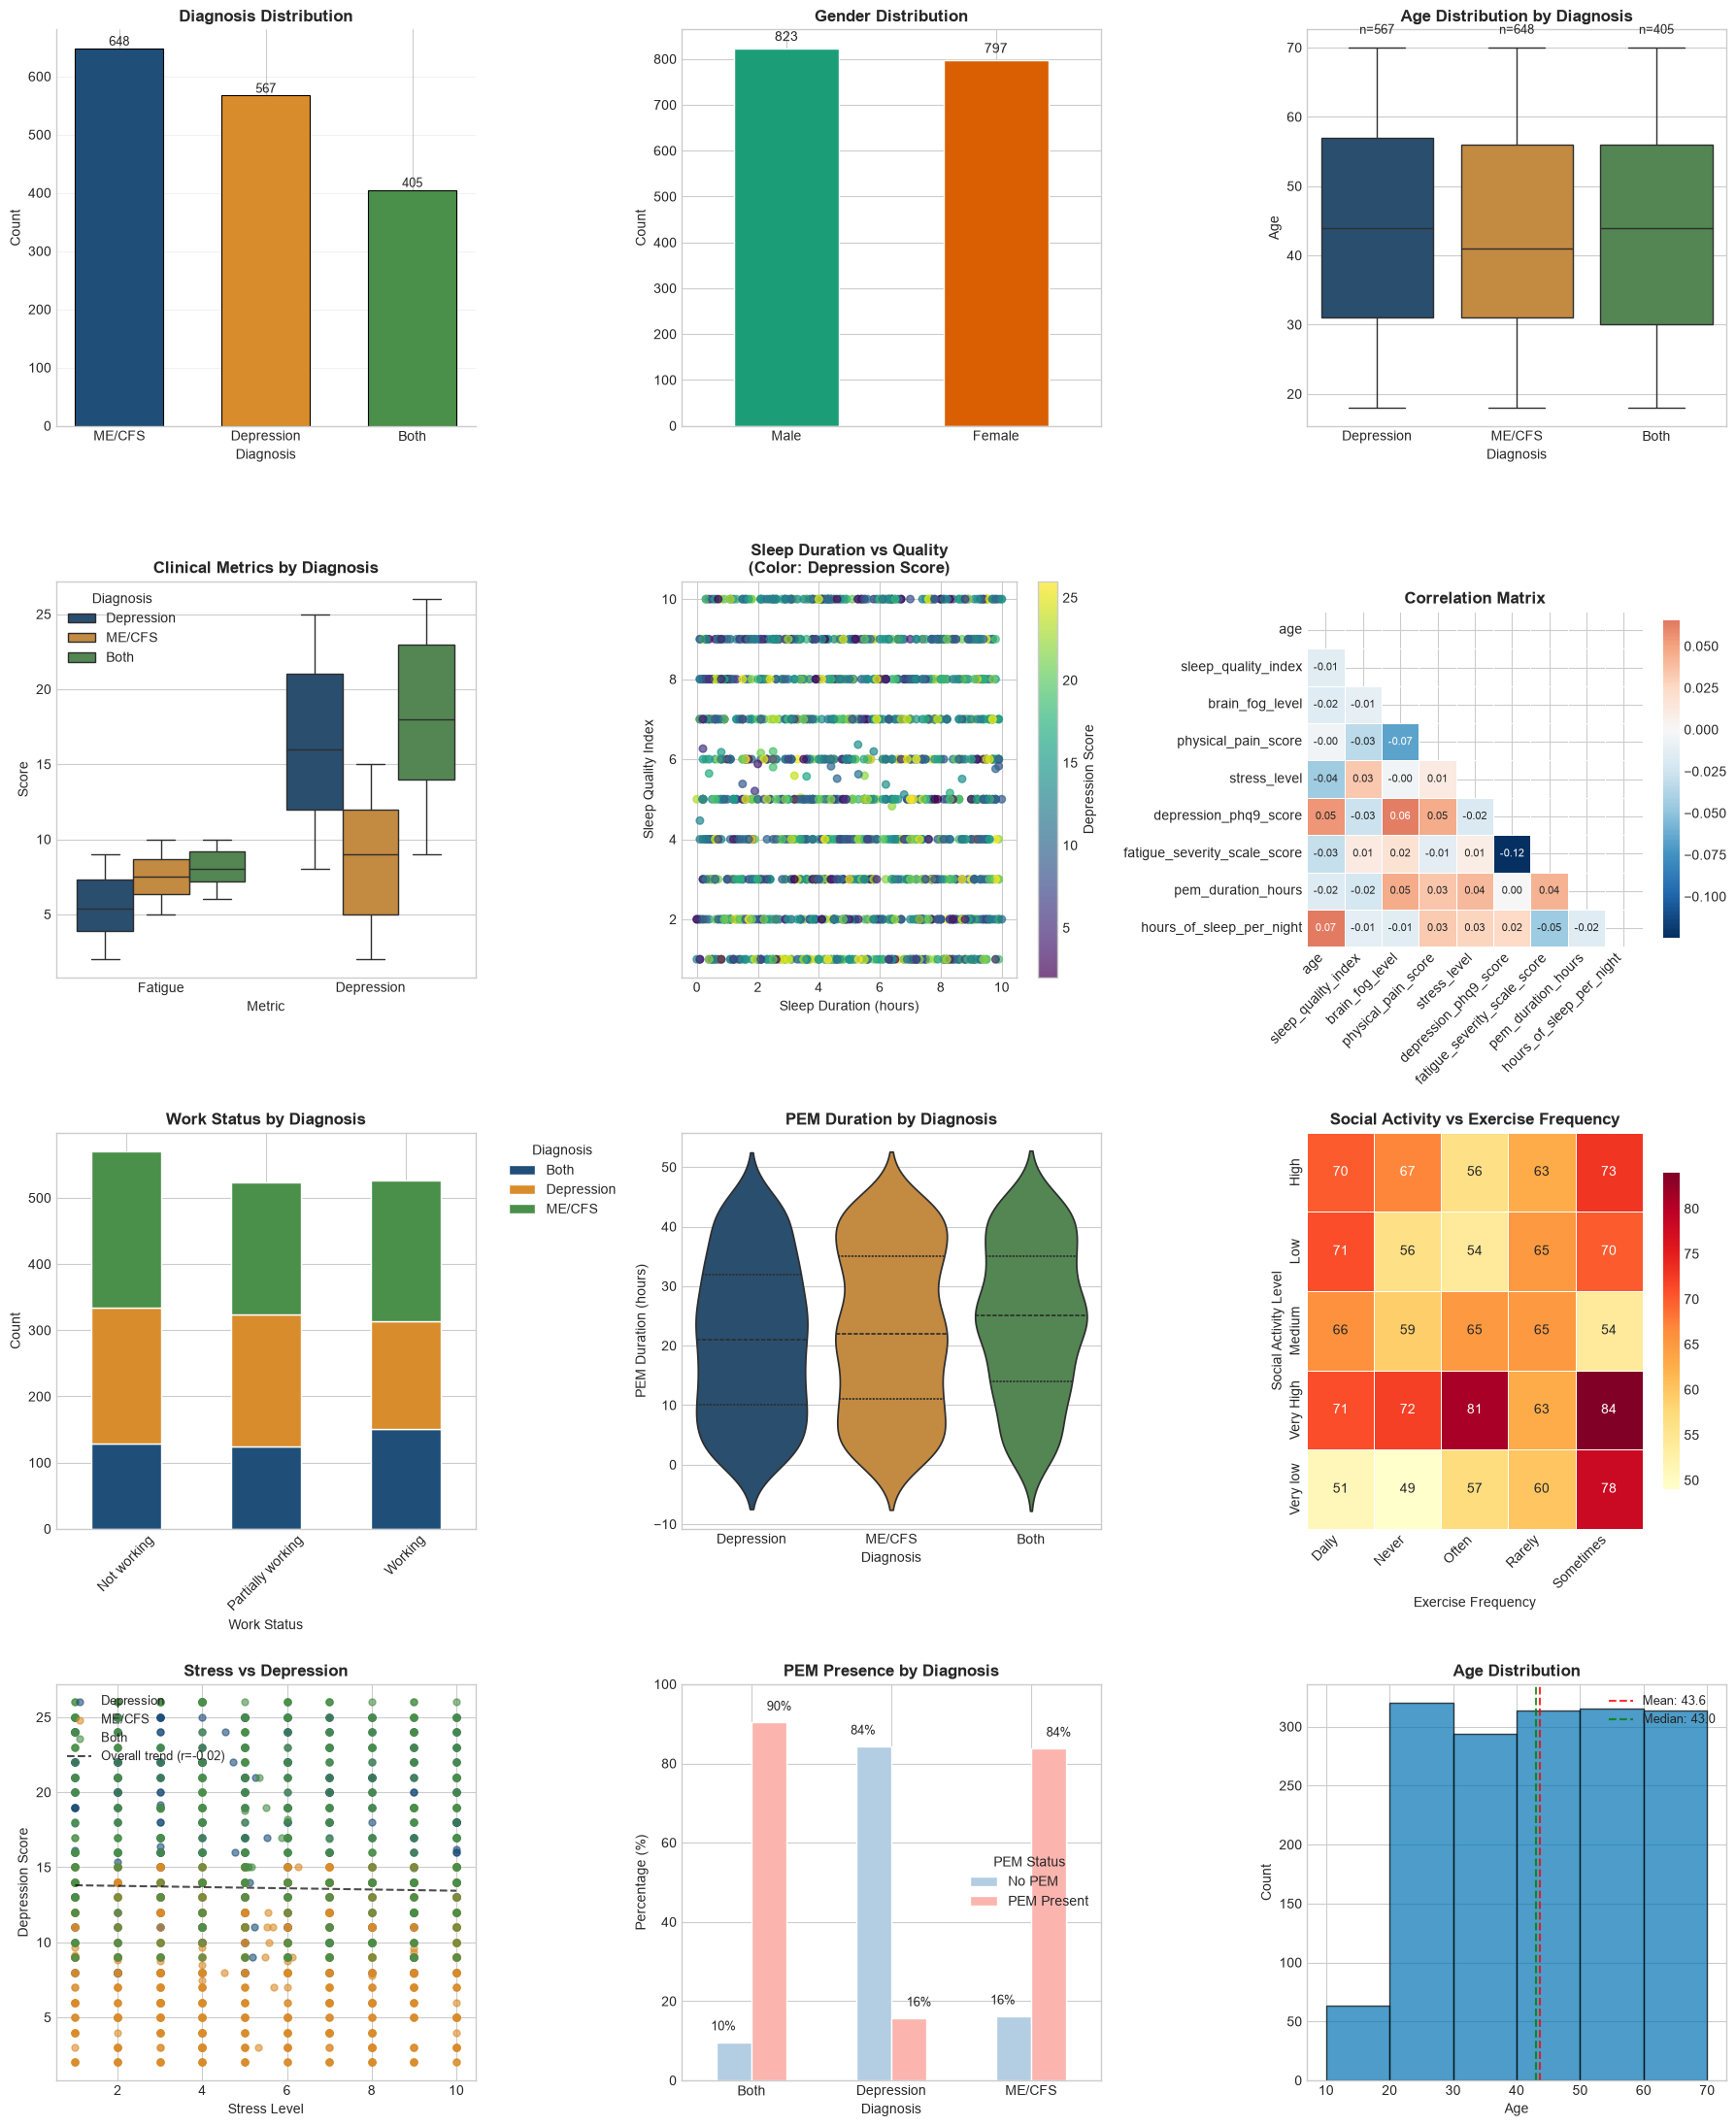

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("colorblind")
fig = plt.figure(figsize=(18, 22))

# Diagnosis distribution (Bar chart)
ax1 = plt.subplot(4, 3, 1)

order = ['ME/CFS', 'Depression', 'Both']
diagnosis_dist = data['diagnosis'].value_counts().reindex(order)
colors = ['#1f4e79', '#d98c2b', '#4a8f4a']

bars = ax1.bar(
    diagnosis_dist.index,
    diagnosis_dist.values,
    color=colors,
    width=0.6,
    edgecolor='black',
    linewidth=0.8
)

ax1.set_title('Diagnosis Distribution', fontsize=12, fontweight='bold')
ax1.set_xlabel('Diagnosis')
ax1.set_ylabel('Count')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.grid(axis='y', alpha=0.25)
ax1.set_axisbelow(True)

for bar in bars:
    h = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width()/2,
        h + 0.5,
        f'{int(h)}',
        ha='center',
        va='bottom',
        fontsize=9
    )


# Gender distribution (Bar chart)
ax2 = plt.subplot(4, 3, 2)
gender_counts = data['gender'].value_counts()
gender_counts.plot(kind='bar', ax=ax2, color=['#1b9e77', '#d95f02'])
ax2.set_title('Gender Distribution', fontsize=12, fontweight='bold')
ax2.set_xlabel('')
ax2.set_ylabel('Count')
ax2.tick_params(axis='x', rotation=0)
for i, v in enumerate(gender_counts):
    ax2.text(i, v + max(gender_counts)*0.02, str(v), 
             ha='center', fontsize=10)


# 3. Age distribution by diagnosis (Box plot)
ax3 = plt.subplot(4, 3, 3)
sns.boxplot(x='diagnosis', y='age', data=data, ax=ax3, 
            palette=colors, showfliers=True)
ax3.set_title('Age Distribution by Diagnosis', fontsize=12, fontweight='bold')
ax3.set_xlabel('Diagnosis')
ax3.set_ylabel('Age')
for i, diagnosis in enumerate(data['diagnosis'].unique()):
    n = sum(data['diagnosis'] == diagnosis)
    ax3.text(i, data['age'].max() + 2, f'n={n}', 
             ha='center', fontsize=9)

# 4. Key clinical metrics by diagnosis (Grouped box plots)
ax4 = plt.subplot(4, 3, 4)
clinical_vars = ['fatigue_severity_scale_score', 'depression_phq9_score']
plot_data = data.melt(id_vars=['diagnosis'], value_vars=clinical_vars,
                     var_name='metric', value_name='score')
sns.boxplot(x='metric', y='score', hue='diagnosis', data=plot_data, 
            ax=ax4, palette=colors)
ax4.set_title('Clinical Metrics by Diagnosis', fontsize=12, fontweight='bold')
ax4.set_xlabel('Metric')
ax4.set_ylabel('Score')
ax4.set_xticklabels(['Fatigue', 'Depression'])
ax4.legend(title='Diagnosis', loc='upper left')


# 5. Sleep duration vs sleep quality (Scatter plot)
ax5 = plt.subplot(4, 3, 5)
scatter = ax5.scatter(data['hours_of_sleep_per_night'], 
                      data['sleep_quality_index'], 
                      c=data['depression_phq9_score'], 
                      cmap='viridis', alpha=0.7, s=30)
ax5.set_xlabel('Sleep Duration (hours)')
ax5.set_ylabel('Sleep Quality Index')
ax5.set_title('Sleep Duration vs Quality\n(Color: Depression Score)', 
              fontsize=12, fontweight='bold')
cbar = plt.colorbar(scatter, ax=ax5)
cbar.set_label('Depression Score')

# Correlation heatmap (Numeric variables)
ax6 = plt.subplot(4, 3, 6)
numeric_vars = ['age', 'sleep_quality_index', 'brain_fog_level', 
                'physical_pain_score', 'stress_level', 'depression_phq9_score',
                'fatigue_severity_scale_score', 'pem_duration_hours',
                'hours_of_sleep_per_night']
corr_matrix = data[numeric_vars].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8},
            ax=ax6, annot=True, fmt='.2f', annot_kws={"size": 8})
ax6.set_title('Correlation Matrix', fontsize=12, fontweight='bold')
ax6.set_xticklabels(ax6.get_xticklabels(), rotation=45, ha='right')

# Work status by diagnosis (Stacked bar chart)
ax7 = plt.subplot(4, 3, 7)
work_cross = pd.crosstab(data['work_status'], data['diagnosis'])
work_cross.plot(kind='bar', stacked=True, ax=ax7, color=colors)
ax7.set_title('Work Status by Diagnosis', fontsize=12, fontweight='bold')
ax7.set_xlabel('Work Status')
ax7.set_ylabel('Count')
ax7.legend(title='Diagnosis', bbox_to_anchor=(1.05, 1), loc='upper left')
ax7.tick_params(axis='x', rotation=45)


# PEM duration by diagnosis (Violin plot)
ax8 = plt.subplot(4, 3, 8)
pem_data = data[data['pem_duration_hours'] <= data['pem_duration_hours'].quantile(0.90)]
sns.violinplot(x='diagnosis', y='pem_duration_hours', data=pem_data, 
               ax=ax8, palette=colors, inner='quartile')
ax8.set_title('PEM Duration by Diagnosis', fontsize=12, fontweight='bold')
ax8.set_xlabel('Diagnosis')
ax8.set_ylabel('PEM Duration (hours)')

# Social activity vs exercise frequency (Heatmap)
ax9 = plt.subplot(4, 3, 9)
social_exercise = pd.crosstab(data['social_activity_level'], 
                              data['exercise_frequency'])
sns.heatmap(social_exercise, annot=True, fmt='d', cmap='YlOrRd', 
            linewidths=0.5, ax=ax9, cbar_kws={"shrink": 0.8})
ax9.set_title('Social Activity vs Exercise Frequency', 
              fontsize=12, fontweight='bold')
ax9.set_xlabel('Exercise Frequency')
ax9.set_ylabel('Social Activity Level')
ax9.set_xticklabels(ax9.get_xticklabels(), rotation=45, ha='right')

#  Stress vs depression by diagnosis (Scatter with regression)
ax10 = plt.subplot(4, 3, 10)
for diagnosis, color in zip(data['diagnosis'].unique(), colors):
    subset = data[data['diagnosis'] == diagnosis]
    ax10.scatter(subset['stress_level'], subset['depression_phq9_score'],
                label=diagnosis, alpha=0.6, s=25, color=color)
    
x = data['stress_level']
y = data['depression_phq9_score']
z = np.polyfit(x, y, 1)
p = np.poly1d(z)
x_range = np.linspace(x.min(), x.max(), 100)
corr_coef = np.corrcoef(x, y)[0, 1]
ax10.plot(x_range, p(x_range), 'k--', alpha=0.7, 
          label=f'Overall trend (r={corr_coef:.2f})')

ax10.set_xlabel('Stress Level')
ax10.set_ylabel('Depression Score')
ax10.set_title('Stress vs Depression', fontsize=12, fontweight='bold')
ax10.legend(loc='upper left', fontsize=9)


# PEM presence by diagnosis (Grouped bar chart)
ax11 = plt.subplot(4, 3, 11)
pem_cross = pd.crosstab(data['diagnosis'], data['pem_present'])
pem_percent = pem_cross.div(pem_cross.sum(axis=1), axis=0) * 100
pem_percent.plot(kind='bar', ax=ax11, color=['#b3cde3', '#fbb4ae'])
ax11.set_title('PEM Presence by Diagnosis', fontsize=12, fontweight='bold')
ax11.set_xlabel('Diagnosis')
ax11.set_ylabel('Percentage (%)')
ax11.set_ylim(0, 100)
ax11.legend(['No PEM', 'PEM Present'], title='PEM Status')
ax11.tick_params(axis='x', rotation=0)
for i, (idx, row) in enumerate(pem_percent.iterrows()):
    for j, val in enumerate(row):
        ax11.text(i + (-0.2 + j*0.4), val + 3, f'{val:.0f}%', 
                 ha='center', fontsize=9)


# Age groups distribution (Histogram)
ax12 = plt.subplot(4, 3, 12)
bins = np.arange(10, 80, 10)
data['age'].hist(bins=bins, ax=ax12, edgecolor='black', alpha=0.7)
ax12.set_title('Age Distribution', fontsize=12, fontweight='bold')
ax12.set_xlabel('Age')
ax12.set_ylabel('Count')
mean_age = data['age'].mean()
median_age = data['age'].median()
ax12.axvline(mean_age, color='red', linestyle='--', alpha=0.8, 
             label=f'Mean: {mean_age:.1f}')
ax12.axvline(median_age, color='green', linestyle='--', alpha=0.8, 
             label=f'Median: {median_age:.1f}')
ax12.legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.show()

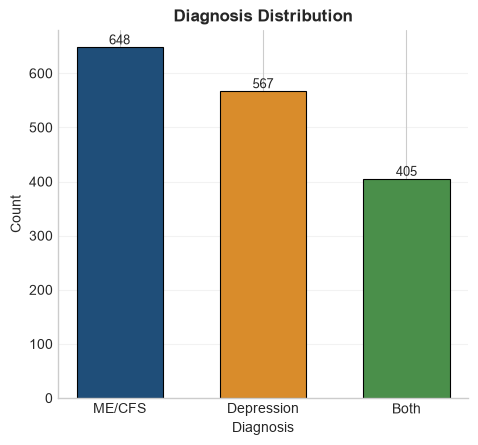

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("colorblind")
fig = plt.figure(figsize=(18, 22))

# Diagnosis distribution (Bar chart)
ax1 = plt.subplot(4, 3, 1)

order = ['ME/CFS', 'Depression', 'Both']
diagnosis_dist = data['diagnosis'].value_counts().reindex(order)
colors = ['#1f4e79', '#d98c2b', '#4a8f4a']

bars = ax1.bar(
    diagnosis_dist.index,
    diagnosis_dist.values,
    color=colors,
    width=0.6,
    edgecolor='black',
    linewidth=0.8
)

ax1.set_title('Diagnosis Distribution', fontsize=12, fontweight='bold')
ax1.set_xlabel('Diagnosis')
ax1.set_ylabel('Count')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.grid(axis='y', alpha=0.25)
ax1.set_axisbelow(True)

for bar in bars:
    h = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width()/2,
        h + 0.5,
        f'{int(h)}',
        ha='center',
        va='bottom',
        fontsize=9
    )

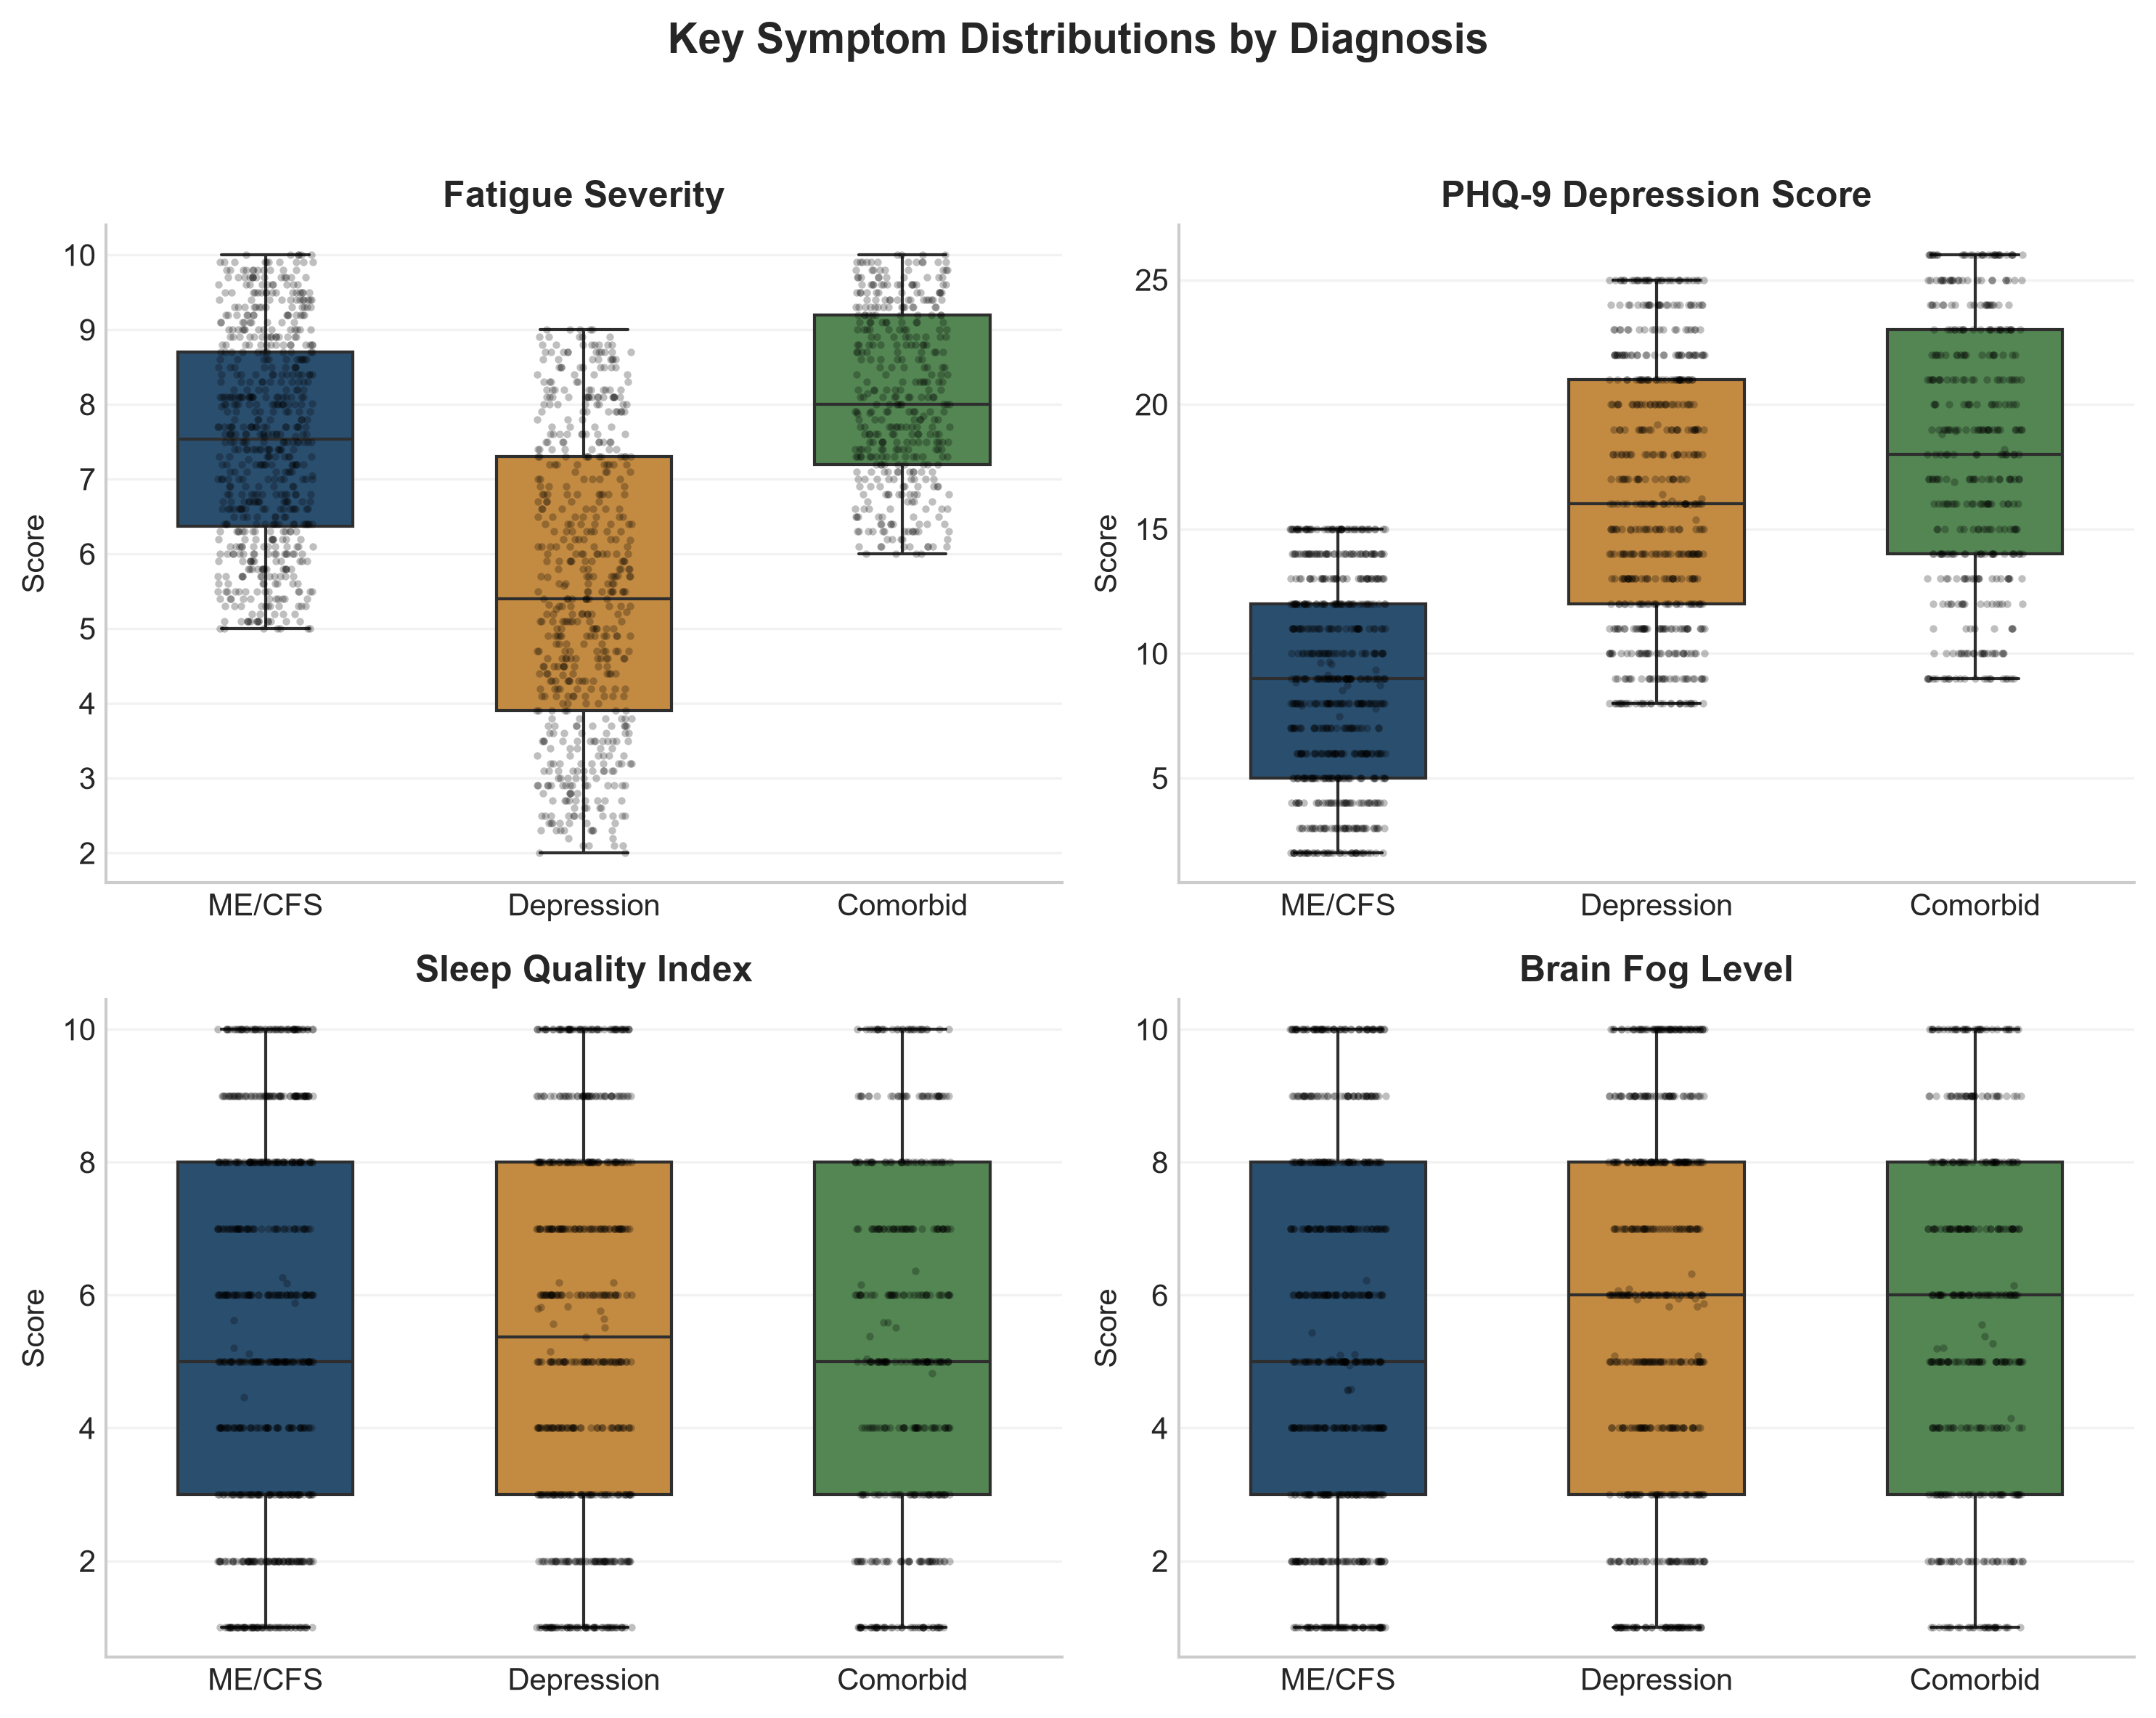

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Fixed diagnosis order
order = ['ME/CFS', 'Depression', 'Both']

# Consistent academic color palette
colors = {
    'ME/CFS': '#1f4e79',
    'Depression': '#d98c2b',
    'Both': '#4a8f4a'
}

# Clinical variables to display
clinical_vars = {
    'fatigue_severity_scale_score': 'Fatigue Severity',
    'depression_phq9_score': 'PHQ-9 Depression Score',
    'sleep_quality_index': 'Sleep Quality Index',
    'brain_fog_level': 'Brain Fog Level'
}

# Create a 2 × 2 figure
fig, axes = plt.subplots(2, 2, figsize=(10, 8), dpi=300)
axes = axes.flatten()

for ax, (variable, label) in zip(axes, clinical_vars.items()):

    plot_data = data[['diagnosis', variable]].dropna()

    # Boxplot
    sns.boxplot(
        data=plot_data,
        x='diagnosis',
        y=variable,
        order=order,
        hue='diagnosis',
        palette=colors,
        legend=False,
        width=0.55,
        showfliers=False,
        ax=ax
    )

    # Add individual data points
    sns.stripplot(
        data=plot_data,
        x='diagnosis',
        y=variable,
        order=order,
        color='black',
        alpha=0.25,
        size=2.5,
        jitter=0.15,
        ax=ax
    )

    ax.set_title(label, fontsize=12, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Score', fontsize=10)

    # Clean academic style
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', alpha=0.25)
    ax.set_axisbelow(True)

    # English x-axis labels
    ax.set_xticklabels([
        'ME/CFS',
        'Depression',
        'Comorbid'
    ])

# Overall figure title
fig.suptitle(
    'Key Symptom Distributions by Diagnosis',
    fontsize=14,
    fontweight='bold'
)

plt.tight_layout(rect=[0, 0, 1, 0.95])

# Save a high-resolution figure
plt.savefig(
    'figure2_key_symptom_distribution.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

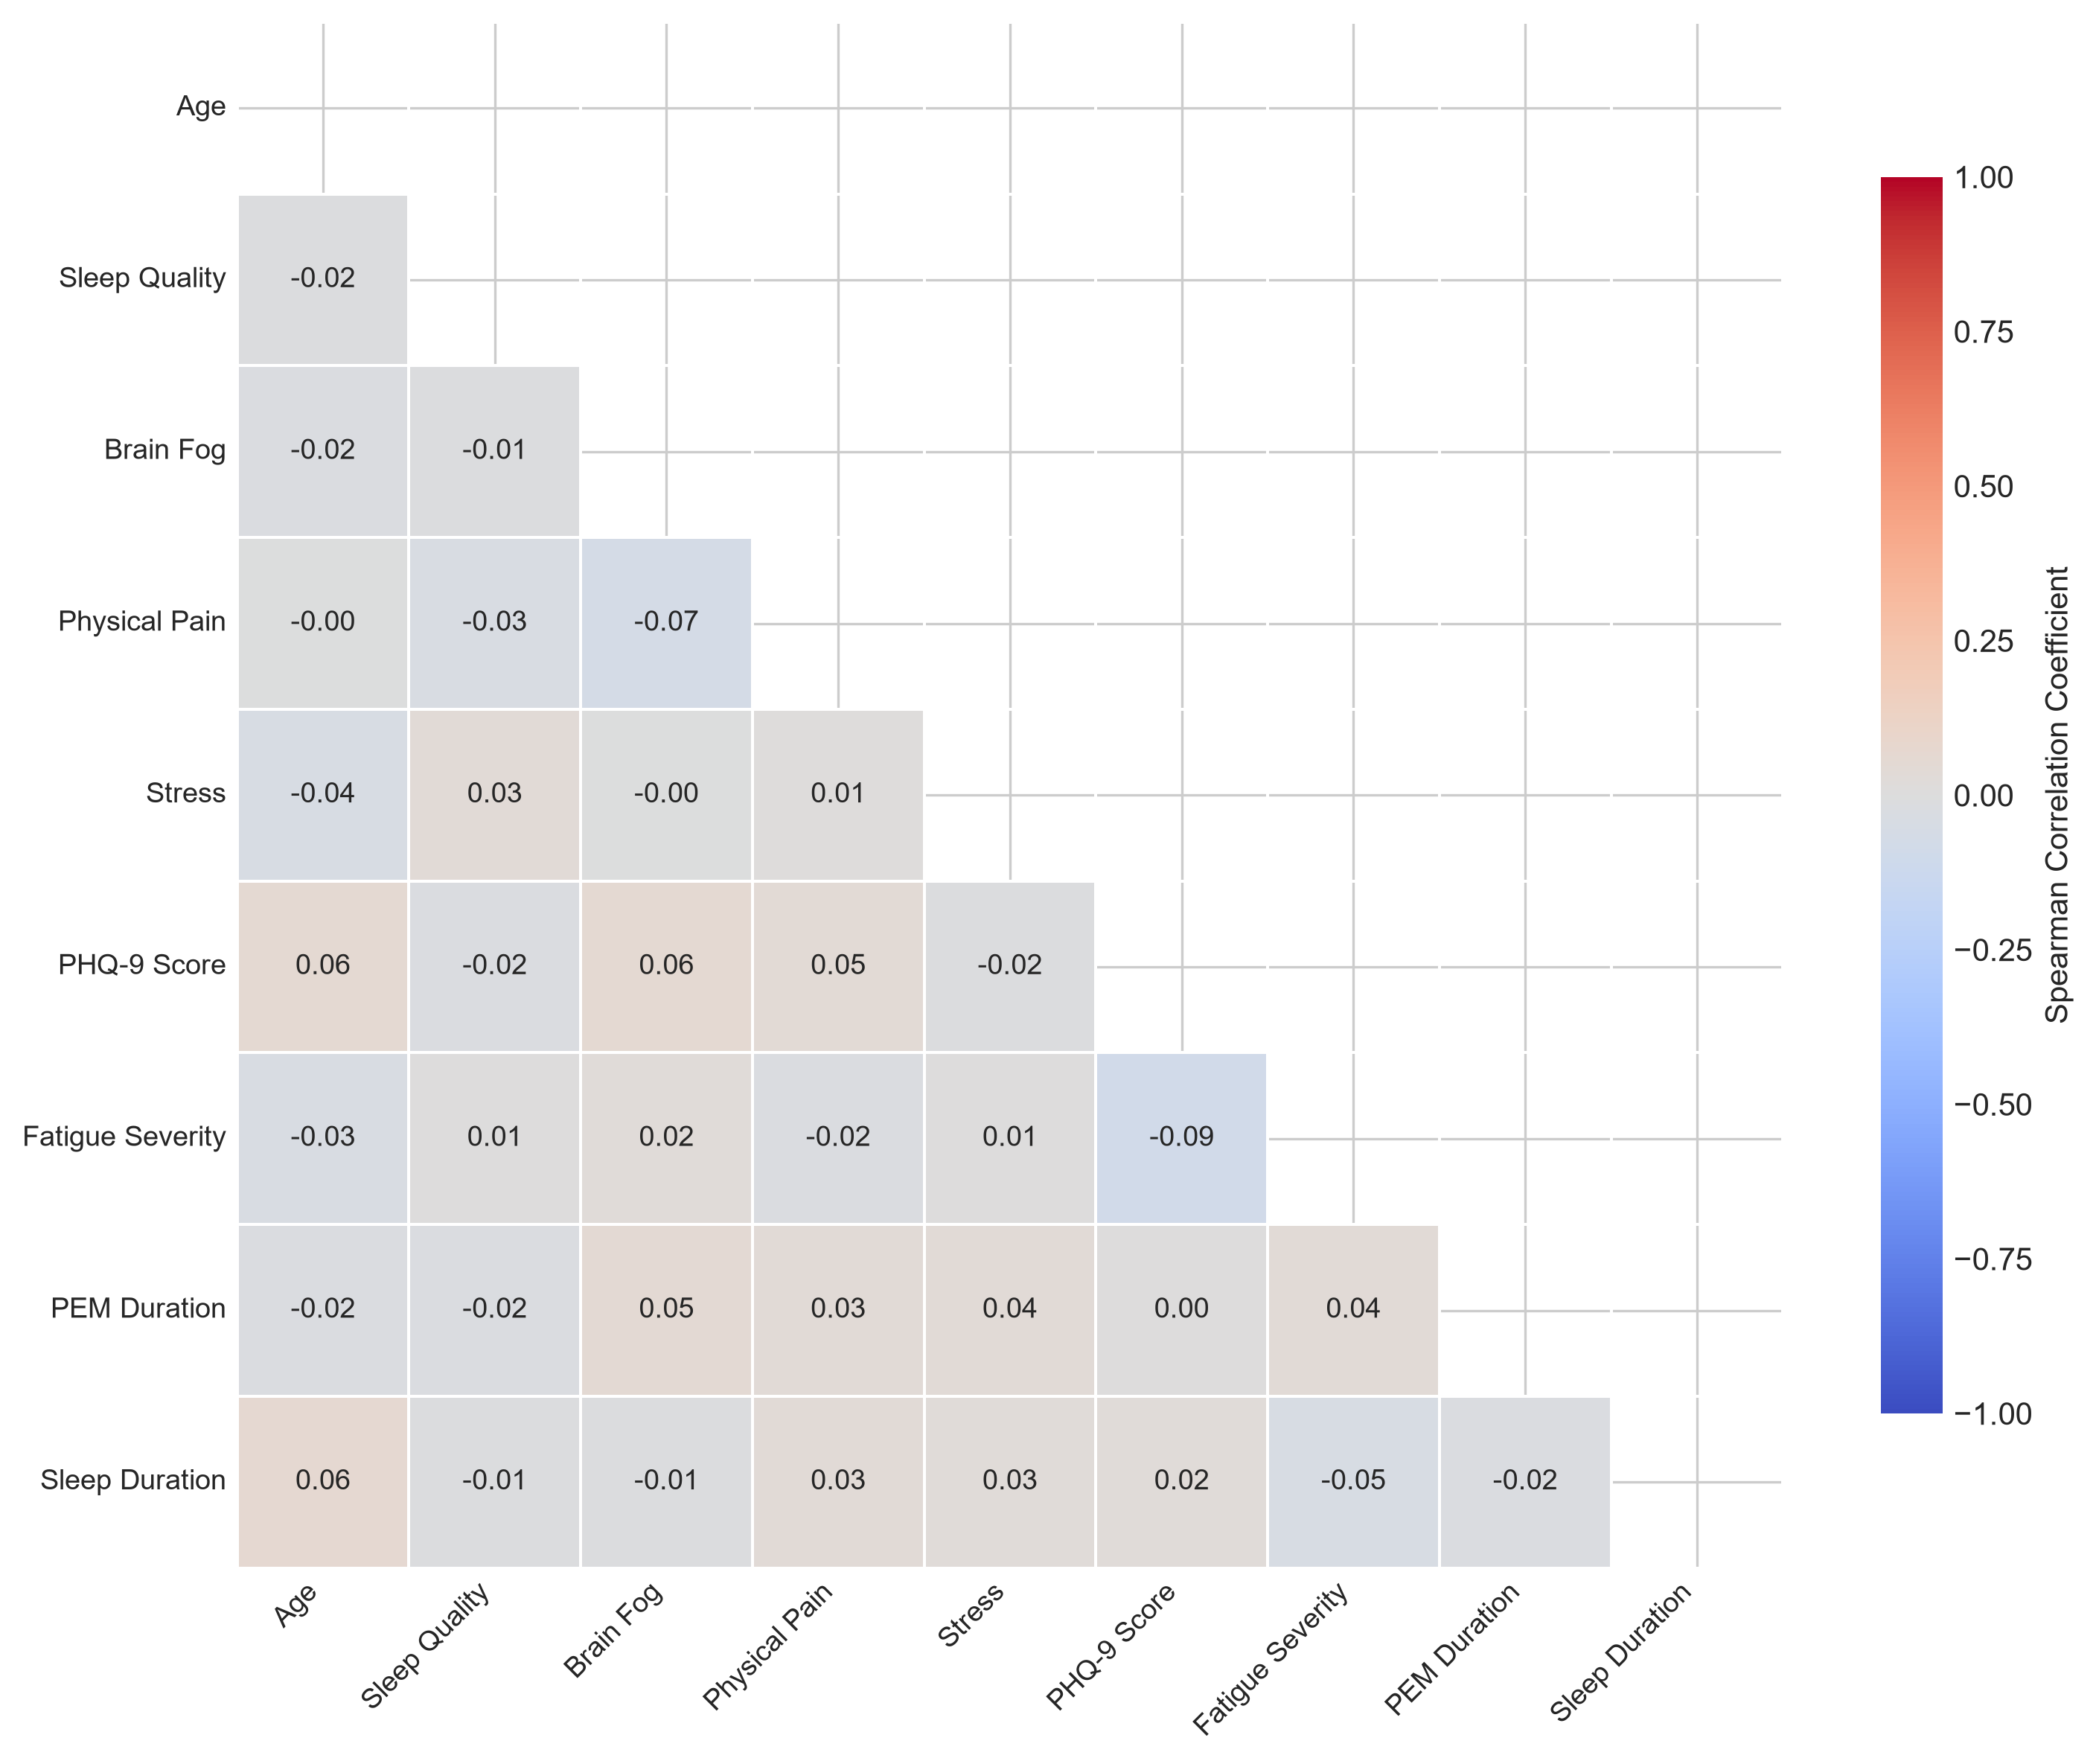

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Select key numerical clinical variables
numeric_vars = [
    'age',
    'sleep_quality_index',
    'brain_fog_level',
    'physical_pain_score',
    'stress_level',
    'depression_phq9_score',
    'fatigue_severity_scale_score',
    'pem_duration_hours',
    'hours_of_sleep_per_night'
]

# More readable labels for the figure
label_map = {
    'age': 'Age',
    'sleep_quality_index': 'Sleep Quality',
    'brain_fog_level': 'Brain Fog',
    'physical_pain_score': 'Physical Pain',
    'stress_level': 'Stress',
    'depression_phq9_score': 'PHQ-9 Score',
    'fatigue_severity_scale_score': 'Fatigue Severity',
    'pem_duration_hours': 'PEM Duration',
    'hours_of_sleep_per_night': 'Sleep Duration'
}

# Calculate Spearman correlation
# Spearman correlation is suitable for clinical and ordinal-type variables
corr_matrix = data[numeric_vars].corr(method='spearman')

# Rename variables for clearer presentation
corr_matrix = corr_matrix.rename(
    index=label_map,
    columns=label_map
)

# Mask the upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Create the figure
fig, ax = plt.subplots(figsize=(10, 8), dpi=300)

sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    center=0,
    annot=True,
    fmt='.2f',
    square=True,
    linewidths=0.5,
    linecolor='white',
    cbar_kws={
        'label': 'Spearman Correlation Coefficient',
        'shrink': 0.8
    },
    annot_kws={
        'size': 9
    },
    ax=ax
)

# Academic figure style
ax.set_xlabel('')
ax.set_ylabel('')

ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=45,
    ha='right',
    fontsize=9
)

ax.set_yticklabels(
    ax.get_yticklabels(),
    rotation=0,
    fontsize=9
)

# Keep the figure clean
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

# Save a high-resolution image
plt.savefig(
    'figure3_correlation_heatmap.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()